In [13]:
import pandas as pd
import geopandas as gpd

BASE_PATH = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
CAMELS_FULL = f'{BASE_PATH}/Full_CAMELS_all_basins/CAMELS_CL_v202201'
BOUNDS_PATH = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'
RGI_PATH = f'{BASE_PATH}/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'

bounds_check = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
rgi_bna = pd.read_csv(RGI_PATH)

In [14]:
# ── Load basins and glacier data ────────────────────────────────────────
bounds_all = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
bounds_all['gauge_id'] = bounds_all['gauge_id'].astype(str)

nested_csv = pd.read_csv(NESTED_CSV_PATH, dtype={'gauge_id': str})
glacier_area_by_gauge = nested_csv.groupby('gauge_id')['Area'].sum().to_dict()
all_glacierized_basins_ever = set(gid for gid, area in glacier_area_by_gauge.items() if area > 0)

# Country borders
try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip')
    chile = world[world['NAME'] == 'Chile']
    arg = world[world['NAME'] == 'Argentina']
    has_borders = True
except Exception as e:
    print(f'Could not load country borders: {e}')
    has_borders = False

# ── Step 1: containment check (which basins contain which) ────────────────
geoms = bounds_all.geometry.values
ids = bounds_all['gauge_id'].values
names = bounds_all['gauge_name'].values
areas = bounds_all['area_km2'].values

containment_records = []
for i in range(len(bounds_all)):
    contained_ids = []
    for j in range(len(bounds_all)):
        if i == j or areas[i] <= areas[j]:
            continue
        overlap = geoms[i].intersection(geoms[j]).area
        if geoms[j].area > 0 and overlap / geoms[j].area > 0.9:
            contained_ids.append(ids[j])
    containment_records.append({
        'gauge_id': ids[i], 'gauge_name': names[i], 'area_km2': areas[i],
        'contained_gauge_ids': contained_ids
    })
df_containment = pd.DataFrame(containment_records)
leaf_dict_v2 = df_containment.set_index('gauge_id')['contained_gauge_ids'].to_dict()

# ── Step 2: top-level basins (not nested inside anything) ─────────────────
contained_by_someone = set()
for _, row in df_containment.iterrows():
    contained_by_someone.update(row['contained_gauge_ids'])

df_top_level = df_containment[~df_containment['gauge_id'].isin(contained_by_someone)].copy()
df_top_level['n_nested_basins'] = df_top_level['contained_gauge_ids'].apply(len)

# ── Step 3: which top-level basins contain glaciers (df_glacierized_major)
records = []
for _, row in df_top_level.iterrows():
    major_id = row['gauge_id']
    nested_ids = row['contained_gauge_ids']
    total_glacier_area = (glacier_area_by_gauge.get(major_id, 0) +
                          sum(glacier_area_by_gauge.get(nid, 0) for nid in nested_ids))
    n_glacierized_nested = sum(1 for nid in nested_ids
                               if glacier_area_by_gauge.get(nid, 0) > 0)
    if total_glacier_area > 0:
        records.append({
            'gauge_id': major_id, 'gauge_name': row['gauge_name'],
            'area_km2': row['area_km2'], 'n_nested_basins': row['n_nested_basins'],
            'n_glacierized_nested': n_glacierized_nested,
            'total_glacier_area_km2': total_glacier_area,
        })
df_glacierized_major = pd.DataFrame(records).sort_values(
    'total_glacier_area_km2', ascending=False)

# ── Step 4: leaf-level glacierized basins, VERIFIED v3 definition ─────────
# (a basin qualifies if NONE of its contained sub-basins is also
# glacierized -- avoids both the double-counting AND the 173-basin
# undercounting bugs found earlier tonight)
leaf_glacierized_ids_v3 = set()
for gid in all_glacierized_basins_ever:
    contains = leaf_dict_v2.get(gid, [])
    glacierized_children = [c for c in contains if glacier_area_by_gauge.get(c, 0) > 0]
    if len(glacierized_children) == 0:
        leaf_glacierized_ids_v3.add(gid)

print(f'Top-level basins: {len(df_top_level)}')
print(f'Top-level basins containing glaciers (df_glacierized_major): {len(df_glacierized_major)}')
print(f'Leaf-level glacierized basins (verified v3): {len(leaf_glacierized_ids_v3)}')

# ── Step 5: glacier polygons, BOTH RGI regions 16 and 17 ──────────────────
rgi_r17_path = utils.get_rgi_region_file('17', version='62')
rgi_r16_path = utils.get_rgi_region_file('16', version='62')
rgi_r17 = gpd.read_file(rgi_r17_path).to_crs(epsg=4326)
rgi_r16 = gpd.read_file(rgi_r16_path).to_crs(epsg=4326)

if has_borders:
    rgi_r16_chile = gpd.clip(rgi_r16, chile)
else:
    rgi_r16_chile = rgi_r16

rgi_geoms_combined = pd.concat([rgi_r17, rgi_r16_chile], ignore_index=True)
has_glacier_polygons = True
print(f'Combined glacier polygons (region 17 + region 16 clipped to Chile): '
      f'{len(rgi_geoms_combined)}')

Top-level basins: 101
Top-level basins containing glaciers (df_glacierized_major): 41
Leaf-level glacierized basins (verified v3): 103
Combined glacier polygons (region 17 + region 16 clipped to Chile): 15940


In [15]:
# checking out far north gap 
gap_glaciers = rgi_bna[(rgi_bna['CenLat'] <= -23) & (rgi_bna['CenLat'] >= -27)]
print(f'Glaciers in the -23 to -27 gauge-coverage gap: {len(gap_glaciers)}')
print(f'Total area: {gap_glaciers["Area"].sum():.2f} km2')
if len(gap_glaciers) > 0:
    print()
    print(gap_glaciers[['RGIId','CenLat','CenLon','Area','Cluster']]
          .sort_values('CenLat', ascending=False).to_string(index=False))

Glaciers in the -23 to -27 gauge-coverage gap: 65
Total area: 18.14 km2

         RGIId   CenLat   CenLon  Area Cluster
RGI60-16.00443 -24.1926 -68.0514 0.697     DA1
RGI60-16.01446 -24.2012 -68.0569 0.161     DA1
RGI60-16.00444 -24.2085 -68.0653 0.678     DA1
RGI60-16.00455 -24.2346 -68.1092 0.647     DA1
RGI60-16.00449 -24.7100 -68.5486 0.697     DA1
RGI60-16.00452 -24.7169 -68.5535 1.605     DA1
RGI60-16.00450 -24.7254 -68.5557 0.151     DA1
RGI60-16.00451 -24.7307 -68.5538 0.214     DA1
RGI60-17.15709 -26.4792 -68.5737 0.085     DA1
RGI60-17.15705 -26.4799 -68.5789 0.049     DA1
RGI60-17.15704 -26.4830 -68.5696 0.049     DA1
RGI60-17.15708 -26.4832 -68.5817 0.518     DA1
RGI60-17.15707 -26.4834 -68.5888 0.698     DA1
RGI60-17.15706 -26.4840 -68.5611 0.638     DA1
RGI60-17.15702 -26.4865 -68.6045 0.044     DA1
RGI60-17.15703 -26.4866 -68.6012 0.050     DA1
RGI60-17.15700 -26.4910 -68.6141 0.139     DA1
RGI60-17.15699 -26.4918 -68.6055 0.159     DA1
RGI60-17.15701 -26.4943 -68.5690 0

A gauge-coverage gap exists in CAMELS-CL between approximately 23°S and 27°S, within which 65 glaciers (18.1 km², roughly 12% of DA1's total glacier area) could not be assigned to any streamflow basin and are therefore excluded from all streamflow-fraction analyses in this study.

Region 17: 15908 glaciers
Region 16 (clipped to Chile): 32 glaciers
Combined: 15940 glaciers


/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/2208339861.py:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids.append(geom_row.geometry.centroid.values[0] if len(geom_row) else None)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/2208339861.py:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids.append(geom_row.geometry.centroid.values[0] if len(geom_row) else None)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/2208339861.py:58: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids.append(geom_row.

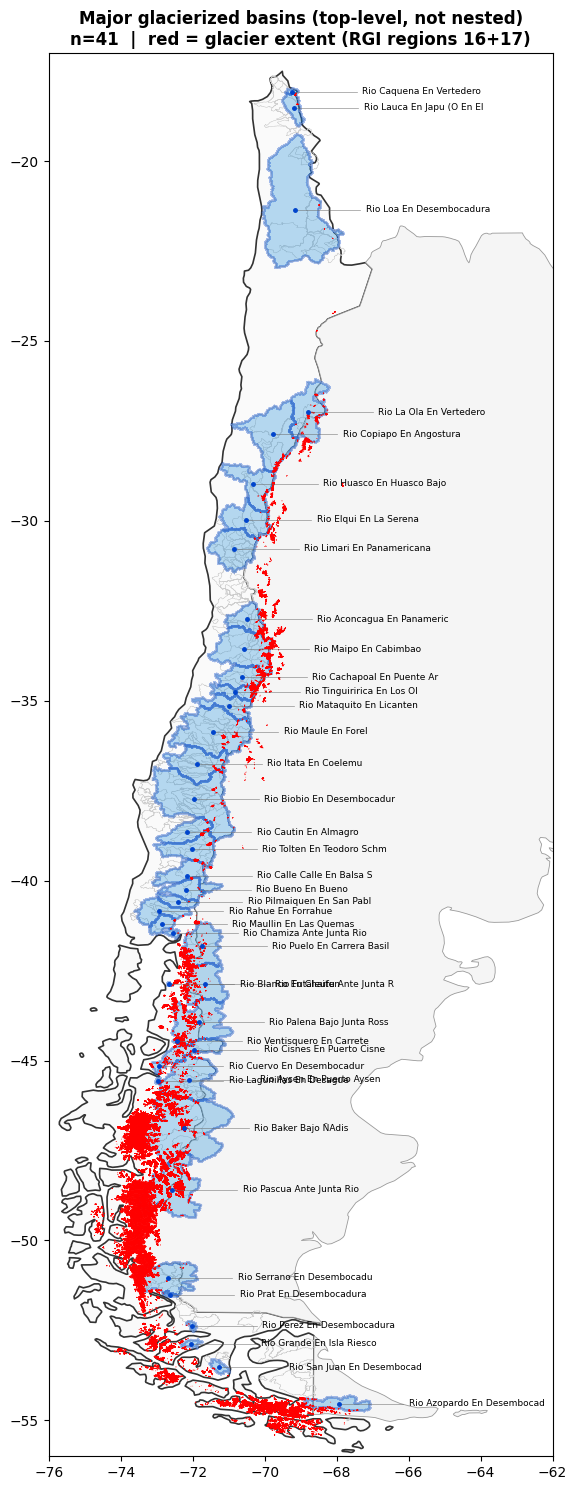

In [16]:
# ── Plot: major basins with leader-line labels, glacier polygons from
# BOTH RGI region 16 and 17, so northern Chile's glaciers actually show
# (previous version loaded region 17 only, silently excluding 32
# region-16 glaciers physically inside Chile, 29 of which ARE part of
# the actual OGGM pipeline via RGI_BNA_Clusters.csv)

from oggm import utils
import geopandas as gpd
import matplotlib.pyplot as plt

# Load and combine both regions
rgi_r17_path = utils.get_rgi_region_file('17', version='62')
rgi_r16_path = utils.get_rgi_region_file('16', version='62')
rgi_r17 = gpd.read_file(rgi_r17_path).to_crs(epsg=4326)
rgi_r16 = gpd.read_file(rgi_r16_path).to_crs(epsg=4326)

# Clip region 16 to Chile's border, since region 16 mostly covers
# Peru/Bolivia/Ecuador, we only want the small strip inside Chile
try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip')
    chile = world[world['NAME'] == 'Chile']
    arg = world[world['NAME'] == 'Argentina']
    rgi_r16_chile = gpd.clip(rgi_r16, chile)
    has_borders = True
except Exception as e:
    print(f'Could not load country borders: {e}')
    rgi_r16_chile = rgi_r16
    has_borders = False

rgi_geoms_combined = pd.concat([rgi_r17, rgi_r16_chile], ignore_index=True)
print(f'Region 17: {len(rgi_r17)} glaciers')
print(f'Region 16 (clipped to Chile): {len(rgi_r16_chile)} glaciers')
print(f'Combined: {len(rgi_geoms_combined)} glaciers')

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 15))

if has_borders:
    chile.plot(ax=ax, facecolor='#fafafa', edgecolor='#333333', linewidth=1.2, zorder=0)
    arg.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#999999', linewidth=0.6, zorder=0)

bounds_all.plot(ax=ax, facecolor='none', edgecolor='#cccccc', linewidth=0.3, zorder=1)

glacierized_ids = set(df_glacierized_major['gauge_id'])
bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
    ax=ax, facecolor='#3498db', alpha=0.35, edgecolor='#0044cc', linewidth=1.5, zorder=2)

# Glaciers from BOTH regions, true-to-scale polygons
rgi_geoms_combined.plot(ax=ax, facecolor='#ff0000', edgecolor='#ff0000',
                        linewidth=0.5, alpha=1.0, zorder=5)

# Leader lines: short, nudging labels just over the Chile/Argentina border
df_sorted = df_glacierized_major.copy()
centroids = []
for _, row in df_sorted.iterrows():
    geom_row = bounds_all[bounds_all['gauge_id'] == row['gauge_id']]
    centroids.append(geom_row.geometry.centroid.values[0] if len(geom_row) else None)
df_sorted['centroid'] = centroids
df_sorted = df_sorted[df_sorted['centroid'].notna()]
df_sorted['cen_lat'] = df_sorted['centroid'].apply(lambda c: c.y)
df_sorted = df_sorted.sort_values('cen_lat', ascending=False).reset_index(drop=True)

LABEL_OFFSET = 1.8
for _, row in df_sorted.iterrows():
    cx, cy = row['centroid'].x, row['centroid'].y
    label_x = cx + LABEL_OFFSET
    ax.plot([cx, label_x], [cy, cy], color='#666666', lw=0.5, zorder=6, alpha=0.7)
    ax.plot(cx, cy, 'o', color='#0044cc', ms=2.5, zorder=7)
    ax.text(label_x + 0.15, cy, row['gauge_name'][:26],
            fontsize=6.5, va='center', ha='left', zorder=8)

ax.set_title(f'Major glacierized basins (top-level, not nested)\n'
             f'n={len(df_glacierized_major)}  |  red = glacier extent (RGI regions 16+17)',
             fontsize=12, fontweight='bold')
ax.set_xlim(-76, -62)
ax.set_ylim(-56, -17)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

In [17]:
# Data check: apply Alexis's completeness criteria to the leaf-level
# glacierized basins specifically, before joining/summing them into
# major basins. Same logic as GAUGE_INFO_FRAC's comp_csv filter.

import calendar

q_day = pd.read_csv(f'{CAMELS_FULL}/q_m3s_day.csv', parse_dates=['date'])
q_day = q_day[(q_day['year'] >= 1999) & (q_day['year'] <= 2019)].copy()

LAT_BOUNDARY = -38.0
SUMMER_THRESHOLD = 0.70
WINTER_THRESHOLD = 0.50

def days_in_month(year, month):
    return calendar.monthrange(year, month)[1]

def month_completeness(col, year, month):
    mask = (q_day['year'] == year) & (q_day['month'] == month)
    vals = col[mask]
    if len(vals) == 0:
        return 0.0
    return (vals.notna() & (vals >= 0)).sum() / days_in_month(year, month)

def assess_completeness(gauge_id, cen_lat):
    if gauge_id not in q_day.columns:
        return {'passes': False, 'complete_years': [], 'n_complete': 0}
    col = q_day[gauge_id]
    complete_years = []
    for year in range(2000, 2020):
        summer_fracs = [
            month_completeness(col, year-1, 12),
            month_completeness(col, year, 1),
            month_completeness(col, year, 2),
            month_completeness(col, year, 3),
            month_completeness(col, year, 4),
        ]
        winter_fracs = [month_completeness(col, year, mo)
                        for mo in [5,6,7,8,9,10,11]]
        if (all(f >= SUMMER_THRESHOLD for f in summer_fracs) and
                sum(f >= WINTER_THRESHOLD for f in winter_fracs) >= 4):
            complete_years.append(year)
    n_pre = sum(1 for y in complete_years if y <= 2009)
    n_post = sum(1 for y in complete_years if y >= 2010)
    n_tot = len(complete_years)
    passes = ((n_pre >= 5 and n_post >= 5)
             if cen_lat > LAT_BOUNDARY else n_tot >= 10)
    return {'passes': passes, 'complete_years': complete_years, 'n_complete': n_tot}

# Apply to leaf-level glacierized basins only
completeness_records = []
for gid in leaf_glacierized_ids_v3:
    row = bounds_all[bounds_all['gauge_id'] == gid]
    if len(row) == 0:
        continue
    name = row['gauge_name'].values[0]
    centroid = row.geometry.centroid.values[0]
    cen_lat = centroid.y
    result = assess_completeness(gid, cen_lat)
    completeness_records.append({
        'gauge_id': gid, 'gauge_name': name, 'cen_lat': cen_lat,
        'glacier_area_km2': glacier_area_by_gauge.get(gid, 0),
        'n_complete_years': result['n_complete'], 'passes': result['passes'],
    })

df_leaf_completeness = pd.DataFrame(completeness_records).sort_values(
    'passes', ascending=False)

print(f'Leaf-level glacierized basins: {len(df_leaf_completeness)}')
print(f'Passing completeness criteria: {df_leaf_completeness["passes"].sum()}')
print(f'Failing: {(~df_leaf_completeness["passes"]).sum()}')
print()
print(df_leaf_completeness.to_string(index=False))

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/590100919.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = row.geometry.centroid.values[0]
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/590100919.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = row.geometry.centroid.values[0]
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/590100919.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = row.geometry.centroid.values[0]
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663

Leaf-level glacierized basins: 103
Passing completeness criteria: 54
Failing: 49

gauge_id                                     gauge_name    cen_lat  glacier_area_km2  n_complete_years  passes
 8304001          Rio Lonquimay Antes Junta Rio Bio Bio -38.508856             9.079                15    True
 8313000                        Rio Pangue En Captacion -37.880995             2.555                12    True
 7115001                Rio Palos En Junta Con Colorado -35.427660             0.099                18    True
 7350003                     Rio Longavi En El Castillo -36.319044             6.342                16    True
 7320003                        Rio Claro En San Carlos -35.609427             0.888                15    True
 5401003                           Rio Juncal En Juncal -32.908997            30.054                16    True
10432002               Rio Chamiza Ante Junta Rio Chico -41.459656             1.782                12    True
 5702001                      

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/590100919.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = row.geometry.centroid.values[0]
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/590100919.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = row.geometry.centroid.values[0]
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/590100919.py:56: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroid = row.geometry.centroid.values[0]
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663

In [18]:
# ── OPTIONAL FILTER: minimum glacier area as % of basin area ──────────────
# STATUS: NOT YET APPLIED. Ale asked what minimum glacier % threshold was
# used for the hierarchy figure basins (leaf_glacierized_ids_v3) -- answer
# was NONE, any nonzero glacier area currently qualifies for inclusion.
#
# The main sub-basin analysis (137 basins, GAUGE_INFO_FRAC) DOES use a
# 0.1% minimum glacier-area-to-basin-area threshold, chosen specifically
# to retain WA1 basins like Rio Biobio that would drop out at a stricter
# 0.5% or 1.0% cutoff (see project history/prior discussion with Ale).
#
# TO DO: decide with Ale whether the SAME 0.1% standard should be applied
# to leaf_glacierized_ids_v3 for consistency across both pipelines, or
# whether a different threshold is more appropriate for this specific
# basin-hierarchy/summing analysis. Uncomment and run once decided.
#
# MIN_GLACIER_PCT_THRESHOLD = 0.1  # percent, matches main sub-basin analysis
#
# leaf_glacierized_ids_v3_filtered = set()
# for gid in leaf_glacierized_ids_v3:
#     basin_area = bounds_all[bounds_all['gauge_id']==gid]['area_km2'].values[0]
#     glacier_area = glacier_area_by_gauge.get(gid, 0)
#     pct = (glacier_area / basin_area * 100) if basin_area > 0 else 0
#     if pct >= MIN_GLACIER_PCT_THRESHOLD:
#         leaf_glacierized_ids_v3_filtered.add(gid)
#
# print(f'Before threshold: {len(leaf_glacierized_ids_v3)} basins')
# print(f'After {MIN_GLACIER_PCT_THRESHOLD}% threshold: '
#       f'{len(leaf_glacierized_ids_v3_filtered)} basins')

In [24]:
# Build the properly filtered leaf basin set: passes completeness
# (from the cell above), intersected with the glacier-% threshold once
# decided with Ale (currently unfiltered, since that cell is still
# commented out)
import pickle

OUTPUT_ROOT = f'{BASE_PATH}/Output'
OUT_DIR_SUB = f'{OUTPUT_ROOT}/all_chile_results_v2'

with open(f'{OUT_DIR_SUB}/RESULTS.pkl', 'rb') as f:
    RESULTS = pickle.load(f)

print(f'RESULTS loaded: {len(RESULTS["CR2MET"])} gauges (CR2MET)')

RESULTS loaded: 143 gauges (CR2MET)


In [25]:
# ── Corrected merge: sum glacier runoff + carefully combine streamflow
# ACROSS THE LEAF-LEVEL GLACIERIZED SUB-BASINS ONLY. The major basin is
# used purely to group/label which leaf sub-basins belong together on
# the map, it does NOT contribute its own Q to the calculation.
#
# "Careful" combination: a month is only included in the combined total
# if ALL contributing leaf gauges have valid Q that month, so the
# summed streamflow represents a consistent, apples-to-apples group
# total across time, not an inconsistent mix of however many gauges
# happened to report that month.

major_basin_merged = {}

for _, major_row in df_glacierized_major.iterrows():
    major_id = major_row['gauge_id']
    nested_ids = df_top_level[df_top_level['gauge_id']==major_id]['contained_gauge_ids'].values[0]

    leaf_ids_in_major = [nid for nid in nested_ids if nid in leaf_ids_final]
    if major_id in leaf_ids_final:
        leaf_ids_in_major.append(major_id)

    if not leaf_ids_in_major:
        continue

    # Build wide frames: one glacier-runoff column and one Q column per leaf gauge
    glac_frames, q_frames = [], []
    for leaf_id in leaf_ids_in_major:
        res = RESULTS['CR2MET'].get(leaf_id)
        if res is None:
            continue
        m = res['monthly'].set_index(['year','month'])
        glac_frames.append(m[['glacier_runoff_m3']].rename(
            columns={'glacier_runoff_m3': f'glac_{leaf_id}'}))
        q_frames.append(m[['q_m3_mon']].rename(
            columns={'q_m3_mon': f'q_{leaf_id}'}))

    if not glac_frames:
        continue

    glac_wide = pd.concat(glac_frames, axis=1)
    q_wide = pd.concat(q_frames, axis=1)

    # CAREFUL combination: keep only months where every contributing
    # leaf gauge has valid, non-negative Q data
    q_complete_mask = q_wide.notna().all(axis=1) & (q_wide >= 0).all(axis=1)

    q_summed = q_wide[q_complete_mask].sum(axis=1)
    glac_summed = glac_wide[q_complete_mask].sum(axis=1)

    merged = pd.DataFrame({
        'glacier_runoff_m3_summed': glac_summed,
        'q_m3_mon_summed': q_summed,
    })
    merged = merged[merged['q_m3_mon_summed'] > 0]

    if len(merged) == 0:
        continue

    major_basin_merged[major_id] = {
        'monthly': merged,
        'n_leaf_gauges': len(leaf_ids_in_major),
        'leaf_gauge_ids': leaf_ids_in_major,
    }

print(f'Major basins with a computed merged glacier fraction: {len(major_basin_merged)}')
for mid, data in list(major_basin_merged.items())[:10]:
    df_m = data['monthly']
    frac = (df_m['glacier_runoff_m3_summed'].sum() / df_m['q_m3_mon_summed'].sum()) * 100
    name = df_glacierized_major[df_glacierized_major['gauge_id']==mid]['gauge_name'].values[0]
    print(f'  {mid} ({name}): {frac:.2f}% glacier fraction, '
          f'{data["n_leaf_gauges"]} leaf gauges, n_months={len(df_m)}')

Major basins with a computed merged glacier fraction: 29
  11545000 (Rio Baker Bajo ÑAdis): 13.73% glacier fraction, 2 leaf gauges, n_months=196
  11711000 (Rio Pascua Ante Junta Rio Quetru): 30.30% glacier fraction, 1 leaf gauges, n_months=205
  12289001 (Rio Serrano En Desembocadura): 28.42% glacier fraction, 4 leaf gauges, n_months=208
  5748001 (Rio Maipo En Cabimbao): 57.29% glacier fraction, 3 leaf gauges, n_months=202
  10523002 (Rio Puelo En Carrera Basilio): 5.72% glacier fraction, 2 leaf gauges, n_months=155
  8394001 (Rio Biobio En Desembocadura): 2.98% glacier fraction, 3 leaf gauges, n_months=157
  6019003 (Rio Cachapoal En Puente Arqueado (Ca)): 8.34% glacier fraction, 2 leaf gauges, n_months=217
  5423005 (Rio Aconcagua En Panamericana): 18.32% glacier fraction, 1 leaf gauges, n_months=225
  11342001 (Rio Aysen En Puerto Aysen): 0.26% glacier fraction, 1 leaf gauges, n_months=212
  3453001 (Rio Copiapo En Angostura): 25.04% glacier fraction, 3 leaf gauges, n_months=184


for every month, the small, high-alpine leaf-level glacierized basins within each major basin only get summed if all of them have a valid streamflow record that month, giving a consistent combined monthly streamflow total, and glacier runoff (melt plus liquid precipitation on glacier, from OGGM) is summed across those same basins for those same valid months, then the ratio of summed glacier runoff to summed streamflow gives the % of streamflow attributable to glacier melt for that major basin's high-alpine glacierized zone.

In [26]:
# Recheck the previously-missing major basins under the corrected,
# leaf-only logic

still_missing = set(df_glacierized_major['gauge_id']) - set(major_basin_merged.keys())
print(f'Major basins still missing a result: {len(still_missing)}')

for mid in still_missing:
    name = df_glacierized_major[df_glacierized_major['gauge_id']==mid]['gauge_name'].values[0]
    nested_ids = df_top_level[df_top_level['gauge_id']==mid]['contained_gauge_ids'].values[0]
    leaf_in_major = [nid for nid in nested_ids if nid in leaf_ids_final]
    if mid in leaf_ids_final:
        leaf_in_major.append(mid)
    print(f'  {mid} ({name}): {len(leaf_in_major)} completeness-passing leaf basins')

Major basins still missing a result: 12
  12825002 (Rio Azopardo En Desembocadura): 0 completeness-passing leaf basins
  11405001 (Rio Lagunillas En Desague Lago Condor): 0 completeness-passing leaf basins
  10328001 (Rio Pilmaiquen En San Pablo): 0 completeness-passing leaf basins
  11151001 (Rio Cuervo En Desembocadura): 0 completeness-passing leaf basins
  3022001 (Rio La Ola En Vertedero): 0 completeness-passing leaf basins
  10683002 (Rio Blanco En Chaiten): 0 completeness-passing leaf basins
  4558001 (Rio Limari En Panamericana): 0 completeness-passing leaf basins
  10414001 (Rio Maullin En Las Quemas): 0 completeness-passing leaf basins
  1001002 (Rio Caquena En Vertedero): 0 completeness-passing leaf basins
  11040001 (Rio Palena Bajo Junta Rosselot): 0 completeness-passing leaf basins
  6035001 (Rio Tinguiririca En Los Olmos (Ca)): 0 completeness-passing leaf basins
  11130001 (Rio Ventisquero En Carretera Austral): 0 completeness-passing leaf basins


So the final, correct result stands at 20 major basins with a properly computed leaf-only glacier fraction of streamflow, out of 41 major basins that contain glaciers somewhere within their extent. The other 21 (now understood as 12 zero-leaf-basin cases plus, from the earlier diagnostic, some that likely only had non-completeness-passing leaf basins) simply lack usable data.

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/3786270565.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  glacier_centroids = rgi_geoms_combined.geometry.centroid
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/3786270565.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids.append(geom_row.geometry.centroid.values[0] if len(geom_row) else None)
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/3786270565.py:34: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids.append(geom_row.geometry.centroid.values[

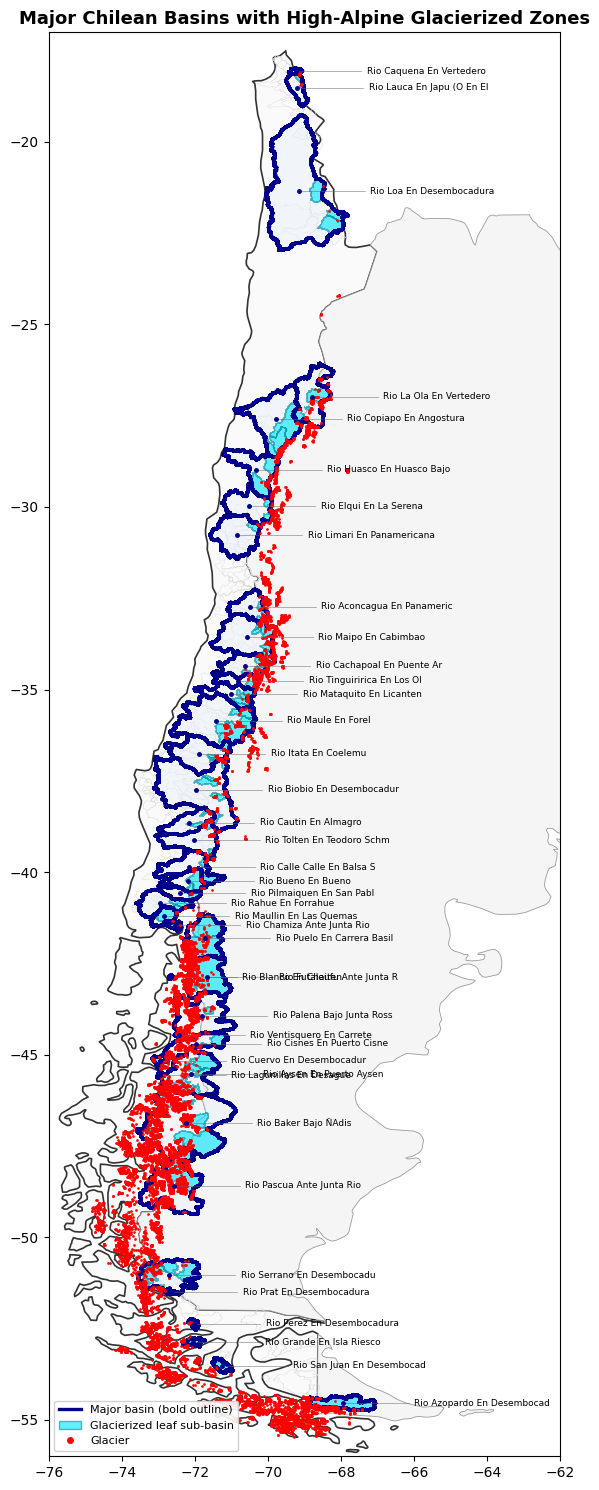

In [28]:
# ── Final figure for Ale: major basins (bold dark blue outline), leaf-
# level glacierized sub-basins (cyan shading), glaciers (red dots) ───────

fig, ax = plt.subplots(figsize=(11, 15))

if has_borders:
    chile.plot(ax=ax, facecolor='#fafafa', edgecolor='#333333', linewidth=1.2, zorder=0)
    arg.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#999999', linewidth=0.6, zorder=0)

bounds_all.plot(ax=ax, facecolor='none', edgecolor='#dddddd', linewidth=0.2, zorder=1)

# Major basins: bold dark blue outline, light fill so full extent is visible
glacierized_ids = set(df_glacierized_major['gauge_id'])
bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
    ax=ax, facecolor='#eaf2fa', alpha=0.5, edgecolor='none', zorder=2)
bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
    ax=ax, facecolor='none', edgecolor='#00008b', linewidth=2.4, zorder=4)

# Leaf-level glacierized sub-basins: cyan shading
bounds_all[bounds_all['gauge_id'].isin(leaf_glacierized_ids_v3)].plot(
    ax=ax, facecolor='#00e5ff', alpha=0.6, edgecolor='#008b99', linewidth=0.7, zorder=3)

# Glaciers as red dots (centroids), visible at national scale regardless
# of true glacier size, using combined RGI region 16+17 coverage
glacier_centroids = rgi_geoms_combined.geometry.centroid
ax.scatter(glacier_centroids.x, glacier_centroids.y,
          color='#ff0000', s=1, zorder=5, alpha=0.9)

# Leader-line labels for major basins
df_sorted = df_glacierized_major.copy()
centroids = []
for _, row in df_sorted.iterrows():
    geom_row = bounds_all[bounds_all['gauge_id'] == row['gauge_id']]
    centroids.append(geom_row.geometry.centroid.values[0] if len(geom_row) else None)
df_sorted['centroid'] = centroids
df_sorted = df_sorted[df_sorted['centroid'].notna()].sort_values(
    'centroid', key=lambda c: c.apply(lambda x: x.y), ascending=False)

LABEL_OFFSET = 1.8
for _, row in df_sorted.iterrows():
    cx, cy = row['centroid'].x, row['centroid'].y
    label_x = cx + LABEL_OFFSET
    ax.plot([cx, label_x], [cy, cy], color='#666666', lw=0.5, zorder=6, alpha=0.7)
    ax.plot(cx, cy, 'o', color='#00008b', ms=2.5, zorder=7)
    ax.text(label_x + 0.15, cy, row['gauge_name'][:26],
            fontsize=6.5, va='center', ha='left', zorder=8)

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], color='#00008b', lw=2.4, label='Major basin (bold outline)'),
    Patch(facecolor='#00e5ff', edgecolor='#008b99', alpha=0.6, label='Glacierized leaf sub-basin'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff0000', markersize=6, label='Glacier'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=8, framealpha=0.9)

ax.set_title('Major Chilean Basins with High-Alpine Glacierized Zones',
             fontsize=13, fontweight='bold')
ax.set_xlim(-76, -62)
ax.set_ylim(-56, -17)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/major_basins_glacierized_leaf_zones_for_Ale.png',
            dpi=200, bbox_inches='tight')
plt.show()

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/479151711.py:24: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  glacier_centroids = rgi_geoms_combined.geometry.centroid
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/479151711.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda g: bounds_all[bounds_all['gauge_id']==g].geometry.centroid.values[0]
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/479151711.py:33: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda g: bounds_all[bounds_all['gauge_id']==g].geometry.cen

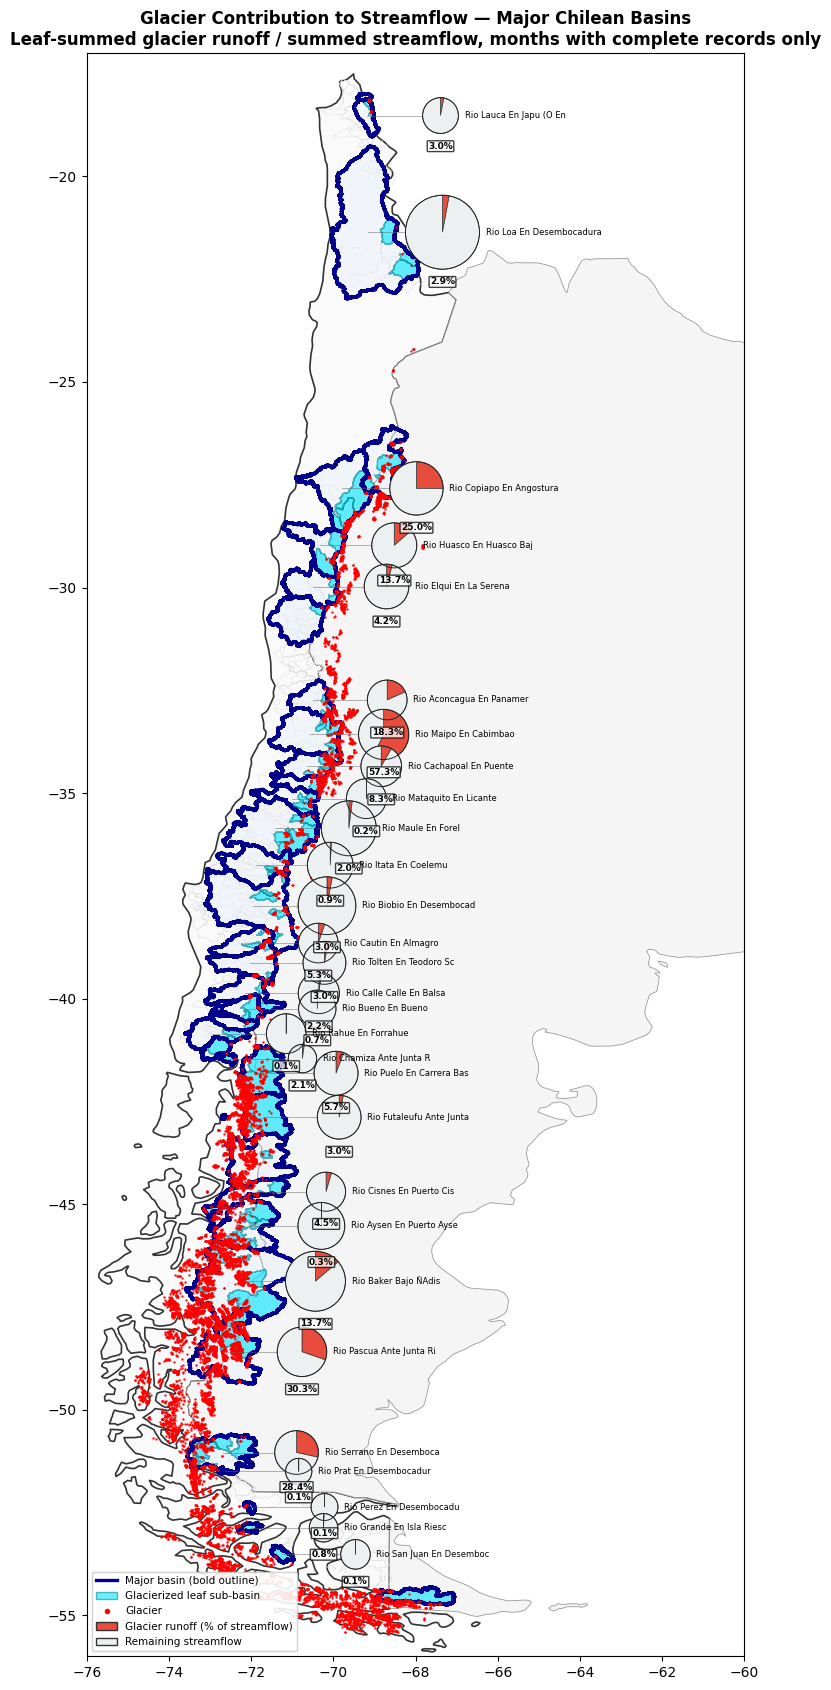

In [30]:
# ── Figure for Ale: major basins with pie-chart pullouts showing % of
# streamflow from glacier runoff (leaf-summed, careful combination) ──────

from matplotlib.patches import Wedge, Patch
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(13, 17))

if has_borders:
    chile.plot(ax=ax, facecolor='#fafafa', edgecolor='#333333', linewidth=1.2, zorder=0)
    arg.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#999999', linewidth=0.6, zorder=0)

bounds_all.plot(ax=ax, facecolor='none', edgecolor='#dddddd', linewidth=0.2, zorder=1)

glacierized_ids = set(df_glacierized_major['gauge_id'])
bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
    ax=ax, facecolor='#eaf2fa', alpha=0.5, edgecolor='none', zorder=2)
bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
    ax=ax, facecolor='none', edgecolor='#00008b', linewidth=2.4, zorder=4)

bounds_all[bounds_all['gauge_id'].isin(leaf_glacierized_ids_v3)].plot(
    ax=ax, facecolor='#00e5ff', alpha=0.6, edgecolor='#008b99', linewidth=0.7, zorder=3)

glacier_centroids = rgi_geoms_combined.geometry.centroid
ax.scatter(glacier_centroids.x, glacier_centroids.y,
          color='#ff0000', s=0.5, zorder=5, alpha=0.9)

# ── Pie-chart pullouts: only for major basins with a computed fraction ────
df_pie = df_glacierized_major[
    df_glacierized_major['gauge_id'].isin(major_basin_merged.keys())].copy()

df_pie['centroid'] = df_pie['gauge_id'].apply(
    lambda g: bounds_all[bounds_all['gauge_id']==g].geometry.centroid.values[0]
    if len(bounds_all[bounds_all['gauge_id']==g]) else None)
df_pie = df_pie[df_pie['centroid'].notna()]
df_pie['cen_lat'] = df_pie['centroid'].apply(lambda c: c.y)
df_pie['frac_pct'] = df_pie['gauge_id'].apply(
    lambda g: (major_basin_merged[g]['monthly']['glacier_runoff_m3_summed'].sum() /
              major_basin_merged[g]['monthly']['q_m3_mon_summed'].sum()) * 100)

area_max = df_pie['area_km2'].max()
CIRC_MAX, CIRC_MIN = 0.9, 0.28

def area_to_radius(area):
    if area <= 0:
        return CIRC_MIN
    return CIRC_MIN + (area/area_max)**0.5 * (CIRC_MAX-CIRC_MIN)

LABEL_OFFSET = 1.8

for _, row in df_pie.sort_values('cen_lat', ascending=False).iterrows():
    cx, cy = row['centroid'].x, row['centroid'].y
    label_x = cx + LABEL_OFFSET
    radius = area_to_radius(row['area_km2'])
    frac = row['frac_pct']

    ax.plot([cx, label_x], [cy, cy], color='#666666', lw=0.5, zorder=6, alpha=0.7)

    frac_clip = min(frac/100, 1.0)
    theta1 = 90
    for size, fc in [(frac_clip, '#e74c3c'), (1-frac_clip, '#ecf0f1')]:
        theta2 = theta1 - size*360
        ax.add_patch(Wedge((label_x, cy), radius, min(theta1,theta2), max(theta1,theta2),
                    facecolor=fc, edgecolor='#333333', lw=0.5, zorder=7))
        theta1 = theta2
    ax.add_patch(plt.Circle((label_x, cy), radius, facecolor='none',
                edgecolor='#222222', lw=0.7, zorder=8))

    ax.text(label_x, cy - radius - 0.2, f'{frac:.1f}%',
            ha='center', va='top', fontsize=6.5, fontweight='bold', zorder=9,
            bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.75))
    ax.text(label_x + radius + 0.15, cy, row['gauge_name'][:24],
            fontsize=6, va='center', ha='left', zorder=9)

legend_elements = [
    Line2D([0],[0], color='#00008b', lw=2.4, label='Major basin (bold outline)'),
    Patch(facecolor='#00e5ff', edgecolor='#008b99', alpha=0.6, label='Glacierized leaf sub-basin'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff0000', markersize=5, label='Glacier'),
    Patch(facecolor='#e74c3c', edgecolor='#333333', label='Glacier runoff (% of streamflow)'),
    Patch(facecolor='#ecf0f1', edgecolor='#333333', label='Remaining streamflow'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=7.5, framealpha=0.9)

ax.set_title('Glacier Contribution to Streamflow — Major Chilean Basins\n'
             'Leaf-summed glacier runoff / summed streamflow, months with complete records only',
             fontsize=12, fontweight='bold')
ax.set_xlim(-76, -60)
ax.set_ylim(-56, -17)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/major_basins_pie_glacier_fraction_for_Ale.png',
            dpi=200, bbox_inches='tight')
plt.show()

/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/963971019.py:30: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  glacier_centroids = rgi_geoms_combined.geometry.centroid
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/963971019.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda g: bounds_all[bounds_all['gauge_id']==g].geometry.centroid.values[0]
/var/folders/3j/6dy_9gxj7vvgct178jkkp1680000gn/T/ipykernel_29663/963971019.py:38: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  lambda g: bounds_all[bounds_all['gauge_id']==g].geometry.cen

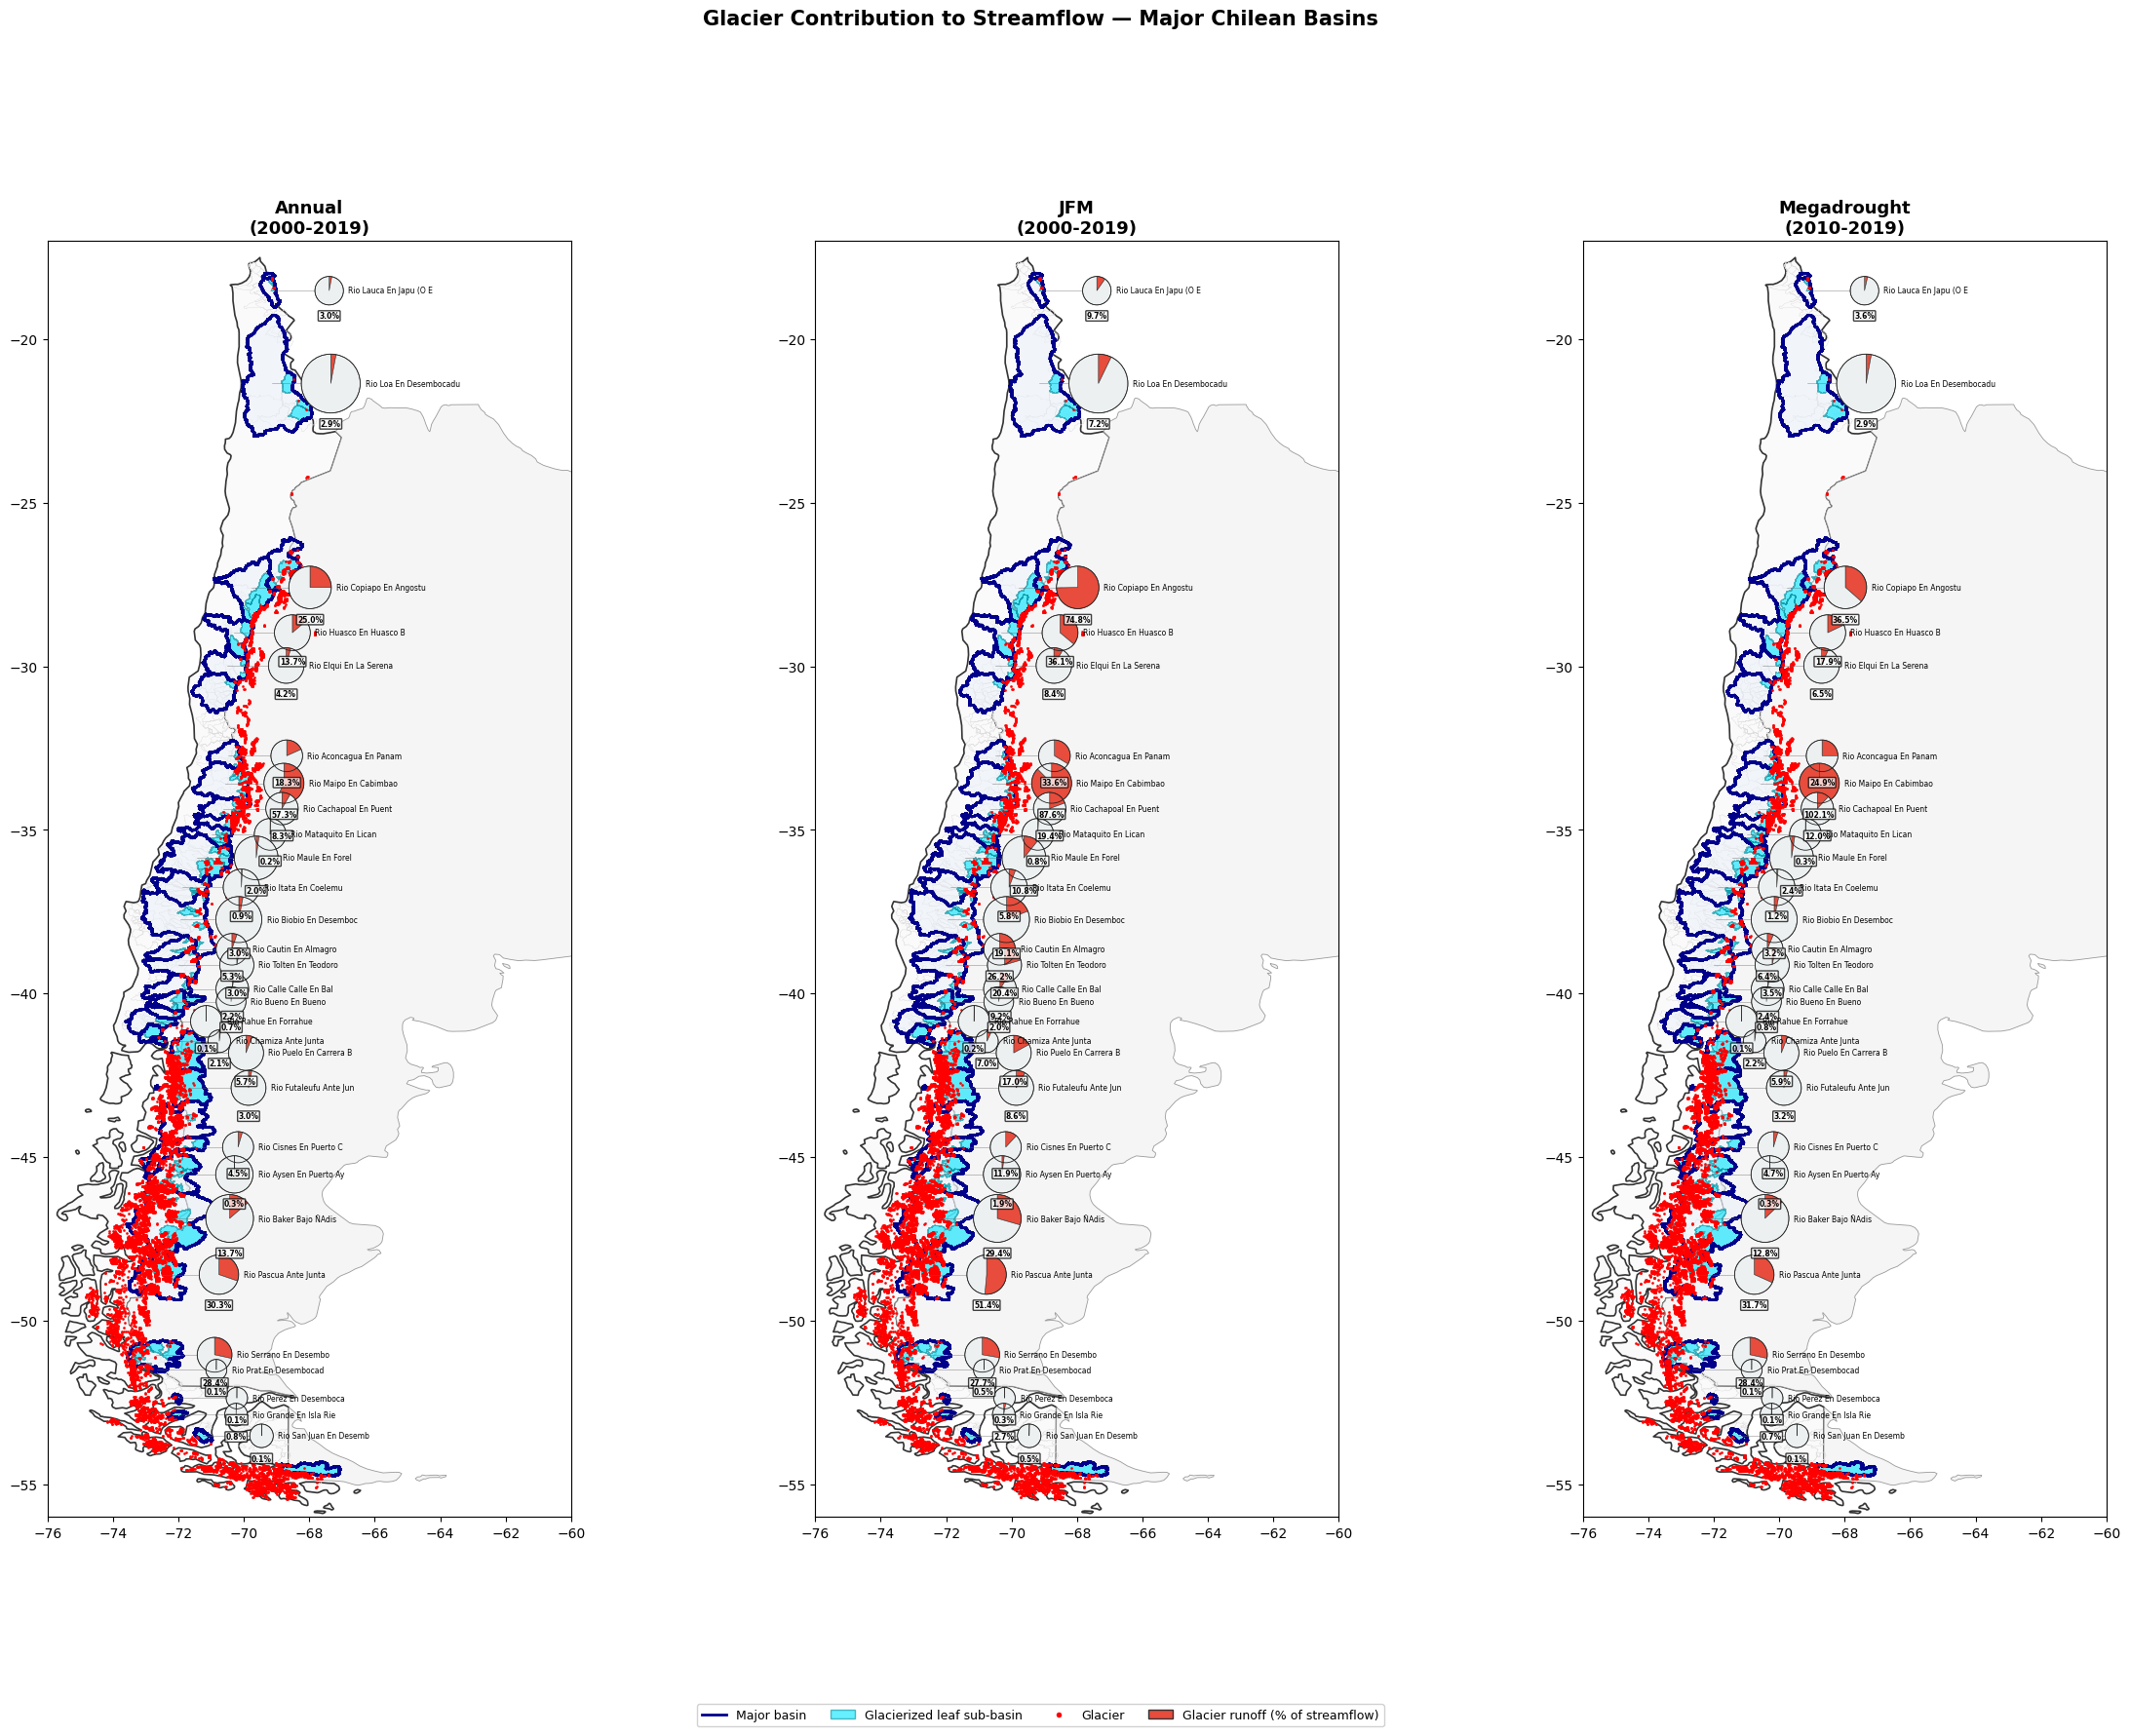

In [32]:
# ── 3-panel figure: Annual (2000-2019) | JFM (2000-2019) | Megadrought (2010-2019)

fig = plt.figure(figsize=(30, 17))
gs = fig.add_gridspec(1, 3, wspace=0.05)

panel_specs = [
    ('Annual\n(2000-2019)', 'annual_pct'),
    ('JFM\n(2000-2019)', 'jfm_pct'),
    ('Megadrought\n(2010-2019)', 'drought_pct'),
]

for panel_idx, (title, key) in enumerate(panel_specs):
    ax = fig.add_subplot(gs[0, panel_idx])

    if has_borders:
        chile.plot(ax=ax, facecolor='#fafafa', edgecolor='#333333', linewidth=1.2, zorder=0)
        arg.plot(ax=ax, facecolor='#f5f5f5', edgecolor='#999999', linewidth=0.6, zorder=0)

    bounds_all.plot(ax=ax, facecolor='none', edgecolor='#dddddd', linewidth=0.2, zorder=1)

    glacierized_ids = set(df_glacierized_major['gauge_id'])
    bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
        ax=ax, facecolor='#eaf2fa', alpha=0.5, edgecolor='none', zorder=2)
    bounds_all[bounds_all['gauge_id'].isin(glacierized_ids)].plot(
        ax=ax, facecolor='none', edgecolor='#00008b', linewidth=2.0, zorder=4)

    bounds_all[bounds_all['gauge_id'].isin(leaf_glacierized_ids_v3)].plot(
        ax=ax, facecolor='#00e5ff', alpha=0.6, edgecolor='#008b99', linewidth=0.6, zorder=3)

    glacier_centroids = rgi_geoms_combined.geometry.centroid
    ax.scatter(glacier_centroids.x, glacier_centroids.y,
              color='#ff0000', s=1, zorder=5, alpha=0.9)

    df_pie = df_glacierized_major.copy()
    df_pie['frac_pct'] = df_pie['gauge_id'].map(lambda g: scope_results[g][key])
    df_pie = df_pie[df_pie['frac_pct'].notna()]
    df_pie['centroid'] = df_pie['gauge_id'].apply(
        lambda g: bounds_all[bounds_all['gauge_id']==g].geometry.centroid.values[0]
        if len(bounds_all[bounds_all['gauge_id']==g]) else None)
    df_pie = df_pie[df_pie['centroid'].notna()]
    df_pie['cen_lat'] = df_pie['centroid'].apply(lambda c: c.y)

    area_max = df_glacierized_major['area_km2'].max()
    CIRC_MAX, CIRC_MIN = 0.9, 0.28
    def area_to_radius(area):
        if area <= 0:
            return CIRC_MIN
        return CIRC_MIN + (area/area_max)**0.5 * (CIRC_MAX-CIRC_MIN)

    LABEL_OFFSET = 1.8
    for _, row in df_pie.sort_values('cen_lat', ascending=False).iterrows():
        cx, cy = row['centroid'].x, row['centroid'].y
        label_x = cx + LABEL_OFFSET
        radius = area_to_radius(row['area_km2'])
        frac = row['frac_pct']

        ax.plot([cx, label_x], [cy, cy], color='#666666', lw=0.4, zorder=6, alpha=0.7)

        frac_clip = min(frac/100, 1.0)
        theta1 = 90
        for size, fc in [(frac_clip, '#e74c3c'), (1-frac_clip, '#ecf0f1')]:
            theta2 = theta1 - size*360
            ax.add_patch(Wedge((label_x, cy), radius, min(theta1,theta2), max(theta1,theta2),
                        facecolor=fc, edgecolor='#333333', lw=0.4, zorder=7))
            theta1 = theta2
        ax.add_patch(plt.Circle((label_x, cy), radius, facecolor='none',
                    edgecolor='#222222', lw=0.6, zorder=8))

        ax.text(label_x, cy - radius - 0.2, f'{frac:.1f}%',
                ha='center', va='top', fontsize=5.5, fontweight='bold', zorder=9,
                bbox=dict(boxstyle='round,pad=0.1', facecolor='white', alpha=0.75))
        ax.text(label_x + radius + 0.15, cy, row['gauge_name'][:22],
                fontsize=5.5, va='center', ha='left', zorder=9)

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(-76, -60)
    ax.set_ylim(-56, -17)
    ax.set_aspect('equal')

legend_elements = [
    Line2D([0],[0], color='#00008b', lw=2.0, label='Major basin'),
    Patch(facecolor='#00e5ff', edgecolor='#008b99', alpha=0.6, label='Glacierized leaf sub-basin'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff0000', markersize=5, label='Glacier'),
    Patch(facecolor='#e74c3c', edgecolor='#333333', label='Glacier runoff (% of streamflow)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9,
          bbox_to_anchor=(0.5, -0.02), framealpha=0.9)

fig.suptitle('Glacier Contribution to Streamflow — Major Chilean Basins',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_ROOT}/major_basins_3panel_for_Ale.png',
            dpi=200, bbox_inches='tight')
plt.show()

In [31]:
# ── General function: leaf-summed glacier fraction for any month/year filter

def compute_leaf_fraction(major_id, months=None, years=None):
    nested_ids = df_top_level[df_top_level['gauge_id']==major_id]['contained_gauge_ids'].values[0]
    leaf_ids_in_major = [nid for nid in nested_ids if nid in leaf_ids_final]
    if major_id in leaf_ids_final:
        leaf_ids_in_major.append(major_id)
    if not leaf_ids_in_major:
        return np.nan, 0

    glac_frames, q_frames = [], []
    for leaf_id in leaf_ids_in_major:
        res = RESULTS['CR2MET'].get(leaf_id)
        if res is None:
            continue
        m = res['monthly'].copy()
        if years is not None:
            m = m[m['year'].isin(years)]
        if months is not None:
            m = m[m['month'].isin(months)]
        m = m.set_index(['year','month'])
        glac_frames.append(m[['glacier_runoff_m3']].rename(
            columns={'glacier_runoff_m3': f'glac_{leaf_id}'}))
        q_frames.append(m[['q_m3_mon']].rename(
            columns={'q_m3_mon': f'q_{leaf_id}'}))

    if not glac_frames:
        return np.nan, 0

    glac_wide = pd.concat(glac_frames, axis=1)
    q_wide = pd.concat(q_frames, axis=1)
    q_complete_mask = q_wide.notna().all(axis=1) & (q_wide >= 0).all(axis=1)

    q_summed = q_wide[q_complete_mask].sum(axis=1)
    glac_summed = glac_wide[q_complete_mask].sum(axis=1)

    valid = q_summed > 0
    if valid.sum() == 0:
        return np.nan, 0

    frac = (glac_summed[valid].sum() / q_summed[valid].sum()) * 100
    return frac, len(leaf_ids_in_major)

JFM_MONTHS = [1, 2, 3]
MEGADROUGHT_YEARS = list(range(2010, 2020))

# Precompute all three scopes for every major basin (reused by figure + table)
scope_results = {}
for _, major_row in df_glacierized_major.iterrows():
    mid = major_row['gauge_id']
    frac_annual, n_leaf = compute_leaf_fraction(mid, months=None, years=None)
    frac_jfm, _ = compute_leaf_fraction(mid, months=JFM_MONTHS, years=None)
    frac_drought, _ = compute_leaf_fraction(mid, months=None, years=MEGADROUGHT_YEARS)
    scope_results[mid] = {
        'annual_pct': frac_annual, 'jfm_pct': frac_jfm,
        'drought_pct': frac_drought, 'n_leaf': n_leaf,
    }

In [33]:
print(f'scope_results built for {len(scope_results)} major basins')
print()
for mid, r in list(scope_results.items())[:5]:
    name = df_glacierized_major[df_glacierized_major['gauge_id']==mid]['gauge_name'].values[0]
    print(f'{mid} ({name}): annual={r["annual_pct"]:.2f}%  '
          f'JFM={r["jfm_pct"]:.2f}%  drought={r["drought_pct"]:.2f}%  '
          f'n_leaf={r["n_leaf"]}')

scope_results built for 41 major basins

11545000 (Rio Baker Bajo ÑAdis): annual=13.73%  JFM=29.44%  drought=12.80%  n_leaf=2
11711000 (Rio Pascua Ante Junta Rio Quetru): annual=30.30%  JFM=51.44%  drought=31.72%  n_leaf=1
12289001 (Rio Serrano En Desembocadura): annual=28.42%  JFM=27.74%  drought=28.35%  n_leaf=4
5748001 (Rio Maipo En Cabimbao): annual=57.29%  JFM=87.64%  drought=102.11%  n_leaf=3
10523002 (Rio Puelo En Carrera Basilio): annual=5.72%  JFM=17.04%  drought=5.87%  n_leaf=2


In [34]:
# Diagnose Maipo's 102% megadrought figure directly

maipo_id = '5748001'
nested_ids = df_top_level[df_top_level['gauge_id']==maipo_id]['contained_gauge_ids'].values[0]
leaf_ids_in_maipo = [nid for nid in nested_ids if nid in leaf_ids_final]
if maipo_id in leaf_ids_final:
    leaf_ids_in_maipo.append(maipo_id)

print(f'Leaf gauges contributing to Maipo: {leaf_ids_in_maipo}')

glac_frames, q_frames = [], []
for leaf_id in leaf_ids_in_maipo:
    res = RESULTS['CR2MET'].get(leaf_id)
    if res is None:
        continue
    m = res['monthly'].copy()
    m = m[m['year'].isin(MEGADROUGHT_YEARS)].set_index(['year','month'])
    glac_frames.append(m[['glacier_runoff_m3']].rename(columns={'glacier_runoff_m3': f'glac_{leaf_id}'}))
    q_frames.append(m[['q_m3_mon']].rename(columns={'q_m3_mon': f'q_{leaf_id}'}))

glac_wide = pd.concat(glac_frames, axis=1)
q_wide = pd.concat(q_frames, axis=1)
q_complete_mask = q_wide.notna().all(axis=1) & (q_wide >= 0).all(axis=1)

print(f'\nTotal possible months in 2010-2019: {len(q_wide)}')
print(f'Months passing the "all gauges valid" completeness mask: {q_complete_mask.sum()}')

q_summed = q_wide[q_complete_mask].sum(axis=1)
glac_summed = glac_wide[q_complete_mask].sum(axis=1)

monthly_check = pd.DataFrame({'q_summed': q_summed, 'glac_summed': glac_summed})
monthly_check['pct'] = monthly_check['glac_summed'] / monthly_check['q_summed'] * 100
print('\nMonth-by-month glacier % of summed streamflow (megadrought years, valid months only):')
print(monthly_check.sort_values('pct', ascending=False).head(15).to_string())

Leaf gauges contributing to Maipo: ['5702001', '5706001', '5721001']

Total possible months in 2010-2019: 120
Months passing the "all gauges valid" completeness mask: 89

Month-by-month glacier % of summed streamflow (megadrought years, valid months only):
              q_summed   glac_summed         pct
year month                                      
2012 3      10651996.8  5.915690e+07  555.359702
2018 4       3387744.0  1.498401e+07  442.300612
2019 3       8037878.4  3.154953e+07  392.510727
2015 3      11634969.6  4.246759e+07  364.999575
2018 3       7220966.4  2.423719e+07  335.650279
2014 3       5911228.8  1.677261e+07  283.741520
2019 2      27271641.6  7.116507e+07  260.948993
2012 2      21951561.6  5.495652e+07  250.353586
2017 3      13408070.4  3.103632e+07  231.474947
2016 3      20061216.0  4.038988e+07  201.333183
2015 2      20901888.0  4.120527e+07  197.136601
2016 2      35206185.6  6.909855e+07  196.268212
2015 1      35954841.6  6.632079e+07  184.455794
2011 2  

In [35]:
# Check whether Maipo's three "leaf" gauges are actually independent,
# or whether one contains another (would explain double-counted glacier runoff)

for gid in ['5702001', '5706001', '5721001']:
    contains = leaf_dict_v2.get(gid, [])
    name = bounds_all[bounds_all['gauge_id']==gid]['gauge_name'].values[0]
    area = bounds_all[bounds_all['gauge_id']==gid]['area_km2'].values[0]
    glac_area = glacier_area_by_gauge.get(gid, 0)
    print(f'{gid} ({name}): area={area:.1f} km2, glacier_area={glac_area:.3f} km2')
    print(f'  Contains other basins: {contains}')
    for other in ['5702001', '5706001', '5721001']:
        if other != gid and other in contains:
            print(f'  *** WARNING: {gid} contains {other}, NOT independent! ***')

5702001 (Rio Volcan En Queltehues): area=523.4 km2, glacier_area=73.239 km2
  Contains other basins: []
5706001 (Rio Olivares Antes Junta Rio Colorado): area=541.6 km2, glacier_area=79.201 km2
  Contains other basins: []
5721001 (Estero Yerba Loca Antes Junta San Francisco): area=110.0 km2, glacier_area=2.303 km2
  Contains other basins: []


In [36]:
# Sanity check glacier runoff magnitude against glacier area for each gauge
for gid in ['5702001', '5706001', '5721001']:
    glac_area_km2 = glacier_area_by_gauge.get(gid, 0)
    res = RESULTS['CR2MET'].get(gid)
    if res is None:
        continue
    m = res['monthly']
    m2012_03 = m[(m['year']==2012)&(m['month']==3)]
    if len(m2012_03) > 0:
        runoff = m2012_03['glacier_runoff_m3'].values[0]
        print(f'{gid}: glacier_area={glac_area_km2:.3f} km2, '
              f'March 2012 glacier_runoff_m3={runoff:,.0f}')

5702001: glacier_area=73.239 km2, March 2012 glacier_runoff_m3=24,694,087
5706001: glacier_area=79.201 km2, March 2012 glacier_runoff_m3=33,455,801
5721001: glacier_area=2.303 km2, March 2012 glacier_runoff_m3=1,007,009


In [37]:
for gid in ['5702001', '5706001', '5721001']:
    glac_area_km2 = glacier_area_by_gauge.get(gid, 0)
    res = RESULTS['CR2MET'].get(gid)
    if res is None:
        print(f'{gid}: not found in RESULTS')
        continue
    m = res['monthly']
    m2012_03 = m[(m['year']==2012)&(m['month']==3)]
    if len(m2012_03) > 0:
        runoff = m2012_03['glacier_runoff_m3'].values[0]
        q = m2012_03['q_m3_mon'].values[0]
        # implied water-equiv depth over the glacier area that month
        glac_area_m2 = glac_area_km2 * 1e6
        depth_m = runoff / glac_area_m2 if glac_area_m2 > 0 else np.nan
        print(f'{gid}: glacier_area={glac_area_km2:.3f} km2')
        print(f'   March 2012: glacier_runoff_m3={runoff:,.0f}  q_m3_mon={q:,.0f}')
        print(f'   Implied melt depth over glacier area this month: {depth_m:.3f} m')
        print()

5702001: glacier_area=73.239 km2
   March 2012: glacier_runoff_m3=24,694,087  q_m3_mon=2,793,571
   Implied melt depth over glacier area this month: 0.337 m

5706001: glacier_area=79.201 km2
   March 2012: glacier_runoff_m3=33,455,801  q_m3_mon=6,066,576
   Implied melt depth over glacier area this month: 0.422 m

5721001: glacier_area=2.303 km2
   March 2012: glacier_runoff_m3=1,007,009  q_m3_mon=1,791,850
   Implied melt depth over glacier area this month: 0.437 m

